Ugesh kc

2431328

# Devnagari Handwritten Digit Classification using FCN

## Task 1: Data Preparation

Training set: (17069, 784), Labels: (17069, 10)
Testing set: (3000, 784), Labels: (3000, 10)


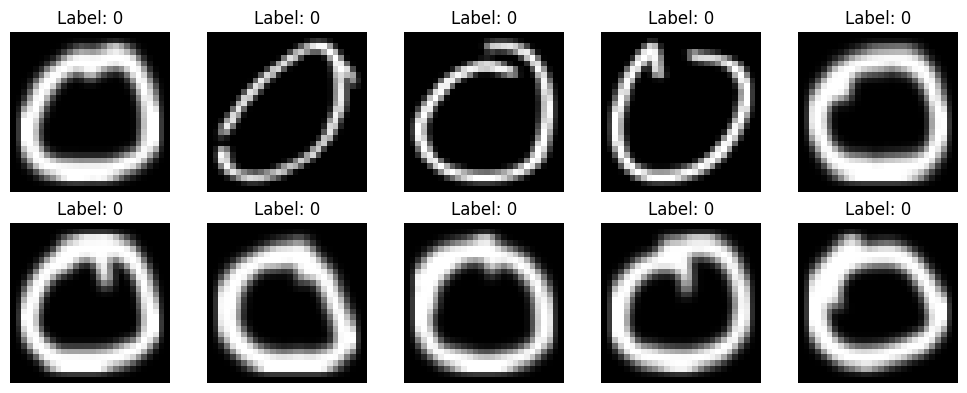

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception:
                pass
    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height * img_width)
x_test = x_test.reshape(-1, img_height * img_width)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Training set: {x_train.shape}, Labels: {y_train_cat.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test_cat.shape}")

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Task 2: Build the FCN Model

In [4]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Task 4: Train the Model

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4685 - loss: 1.6460 - val_accuracy: 0.0041 - val_loss: 8.4929
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8182 - loss: 0.5399 - val_accuracy: 0.0041 - val_loss: 9.8431
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9020 - loss: 0.2973 - val_accuracy: 0.0041 - val_loss: 10.6036
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9479 - loss: 0.1929 - val_accuracy: 0.0041 - val_loss: 10.9596
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9594 - loss: 0.1443 - val_accuracy: 0.0041 - val_loss: 11.1856
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9675 - loss: 0.1128 - val_accuracy: 0.0041 - val_loss: 11.4980


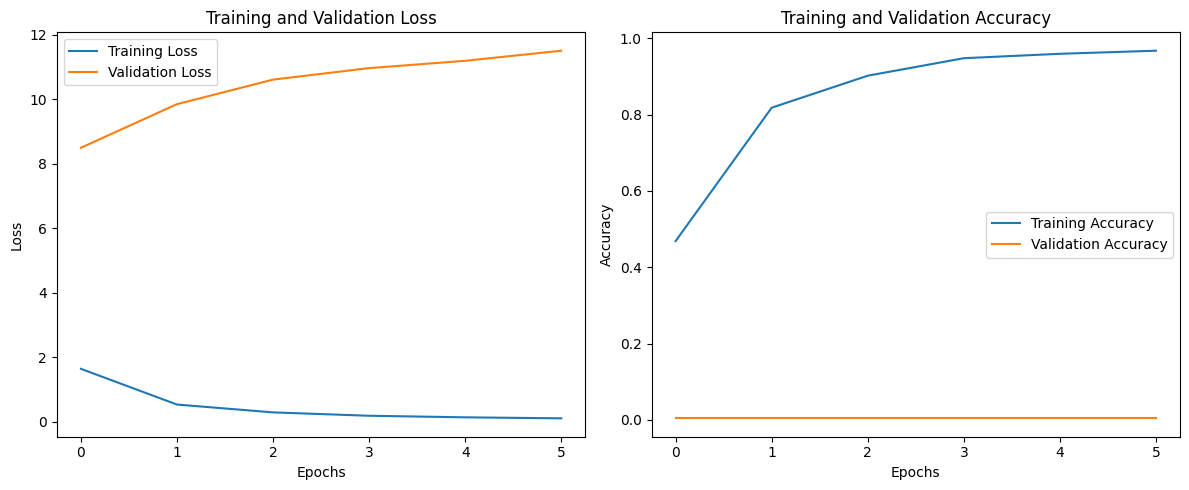

In [6]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath='best_model.keras', save_best_only=True, monitor='val_loss'),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.6033 - loss: 2.3954
Test Loss: 2.3954
Test Accuracy: 0.6033


## Task 6: Save and Load the Model

In [8]:
model.save('devnagari_fcn_model.h5')
print("Model saved to devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Loaded Model - Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved to devnagari_fcn_model.h5
Model loaded successfully
94/94 - 1s - 6ms/step - accuracy: 0.6033 - loss: 2.3954
Loaded Model - Test Loss: 2.3954, Test Accuracy: 0.6033


## Task 7: Predictions

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted label for first image: 0
True label for first image: 0


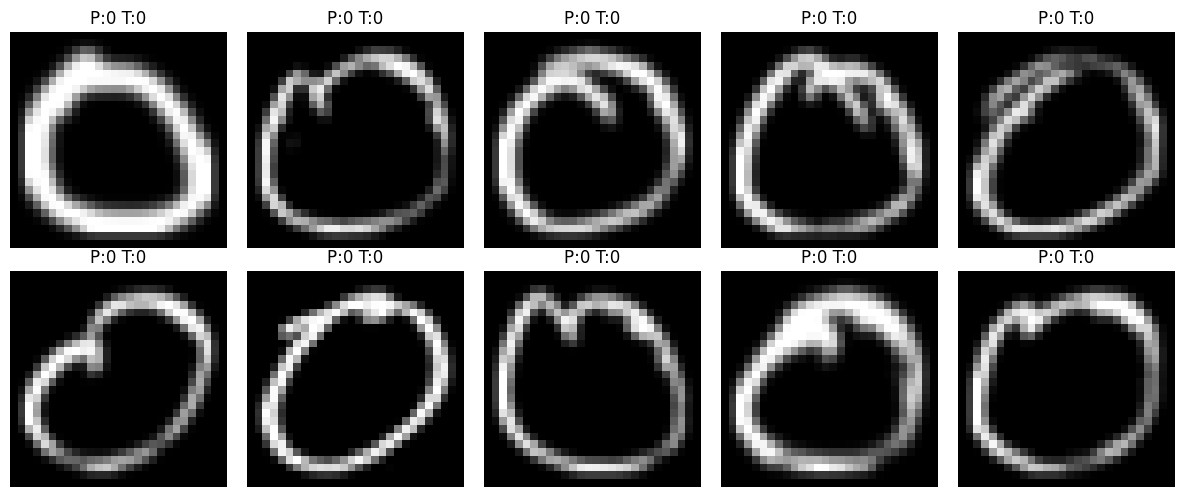

In [9]:
 predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_test[0]}")

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]} T:{y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()